## Interpretability
How well can children learning with a certain algorithm understnd eachother?

In [6]:
# imports
from november_lib import Player, NaiveBayesPlayer, LinearFunctionPlayer, \
    SigmoidPlayer, MLPPlayer, LRPlayer, StrictPlayer, predict_interpretability
import numpy as np
%matplotlib inline
import matplotlib.pyplot as plt

# setup fake board
fake_policy = np.zeros((1000,), dtype=int)
fake_policy[:475] = 1
fake_policy[525:] = 2

In [7]:
# Constants
n_children = 100    # number of children to teach - O(n_children^2)
states = 1000
signals = 2
samples = 200
threshold = 0.8

info = (signals, states, samples, threshold)

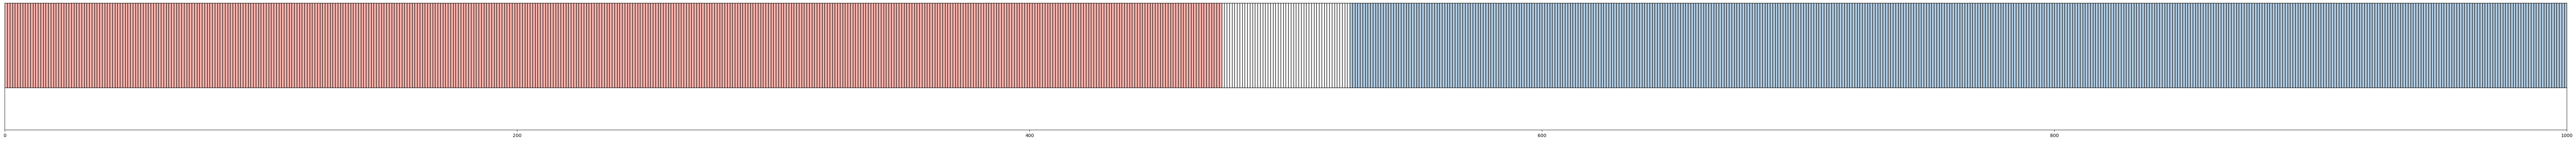

In [8]:
temp = Player(policy=fake_policy, n_signals=signals, n_states=states)
plt.figure(figsize=(100, 5))
ax = plt.gca()
ax = temp.plot_strategy(ax)
plt.show()

`predict_interpretability()` is passed a policy and an algorithm type along with some basic game parameters, set above. It teaches `n_children` unique "children" which play one _random_ round with a parent who's policy is the passed `policy` argument. Then, each unique pair of children is scored for utility. The average of these utility scores, or interpretability, is then returned.

In pseudocode:
```
parent = Player(policy)
for i in range(n_children):
    child = new Player()
    examples = parent.poll(n_samples)
    child.learn(examples, threshold)
    child -> child_list

for i in range(n_children)
    for j in range(i+1, n_children):
        score = child_list[i].utility(child_list[j])
        score -> scores

return sum(scores) / len(scores)
```

### Basic player
Implements KNN.

Average interpretability: 0.9899419191919057
Greatest disagreement: 0.969


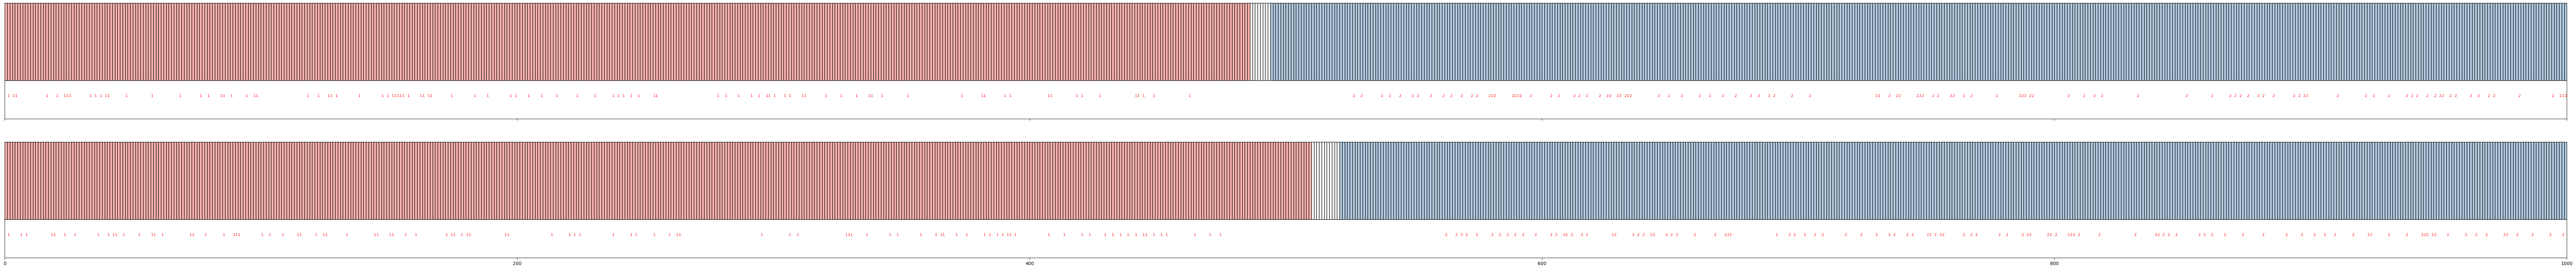

In [9]:
avg, lo_score, lo_pair = predict_interpretability(fake_policy, Player, info, n_children)
print(f"Average interpretability: {avg}")
print(f"Greatest disagreement: {lo_score}")
_, ax = plt.subplots(nrows=2, sharex=True, figsize=(100, 10))
ax[0] = lo_pair[0].plot_strategy(ax[0])
ax[1] = lo_pair[1].plot_strategy(ax[1])
plt.show()

### Strict Player
No generalization to unseen states.

Average interpretability: 0.9669372727272696
Greatest disagreement: 0.9405


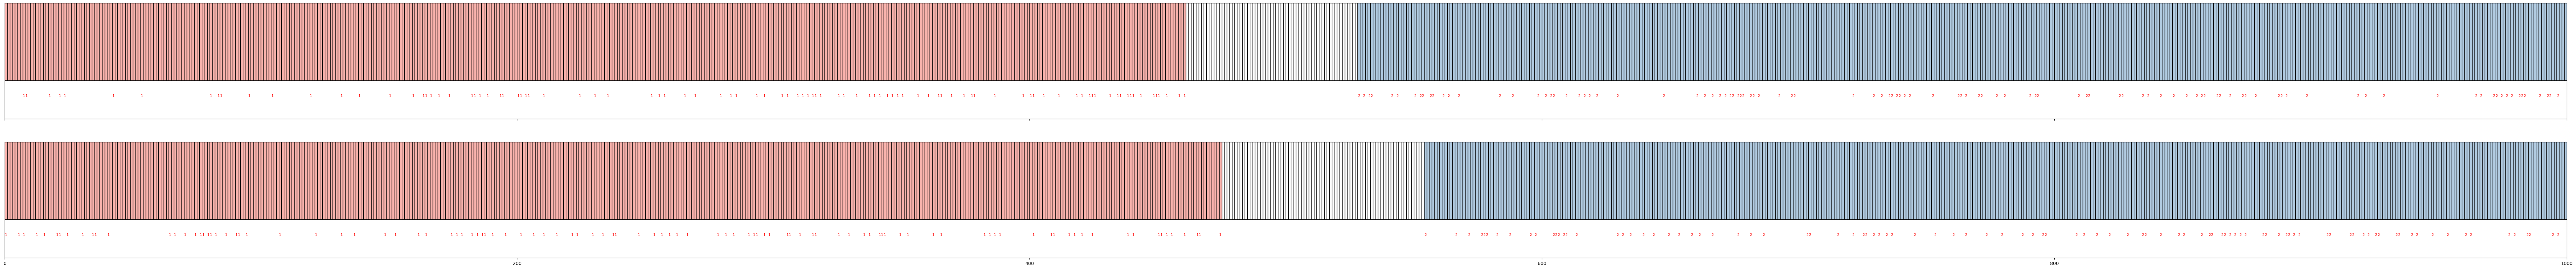

In [10]:
avg, lo_score, lo_pair = predict_interpretability(fake_policy, StrictPlayer, info, n_children)
print(f"Average interpretability: {avg}")
print(f"Greatest disagreement: {lo_score}")
_, ax = plt.subplots(nrows=2, sharex=True, figsize=(100, 10))
ax[0] = lo_pair[0].plot_strategy(ax[0])
ax[1] = lo_pair[1].plot_strategy(ax[1])
plt.show()

### Linear Function Player
Draws a line between `(1(g)_max_, 1)` and `(2(g)_min_, 0)`, with a mirror between `(1(g)_max_, 0)` and `(2(g)_min_, 1)`, to assess signal confidence.

Average interpretability: 0.9788896969696885
Greatest disagreement: 0.9635


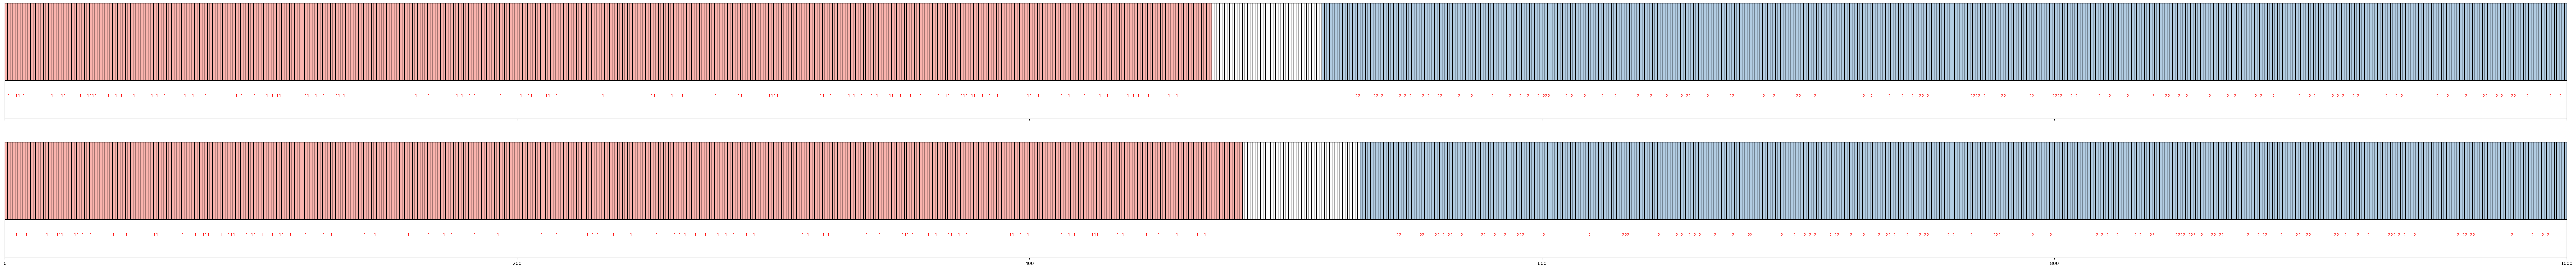

In [11]:
avg, lo_score, lo_pair = predict_interpretability(fake_policy, LinearFunctionPlayer, info, n_children)
print(f"Average interpretability: {avg}")
print(f"Greatest disagreement: {lo_score}")
_, ax = plt.subplots(nrows=2, sharex=True, figsize=(100, 10))
ax[0] = lo_pair[0].plot_strategy(ax[0])
ax[1] = lo_pair[1].plot_strategy(ax[1])
plt.show()

### Sigmoid Player
Draws a sigmoid between `(1(g)_max_, 1)` and `(2(g)_min_, 0)`, with a mirror between `(1(g)_max_, 0)` and `(2(g)_min_, 1)`, to assess signal confidence. Like the linear function, each sigmoid yeilds 0.5 at the halfway point between 1(g)_max_ and 2(g)_min_.

Average interpretability: 0.9864828282828219
Greatest disagreement: 0.9705


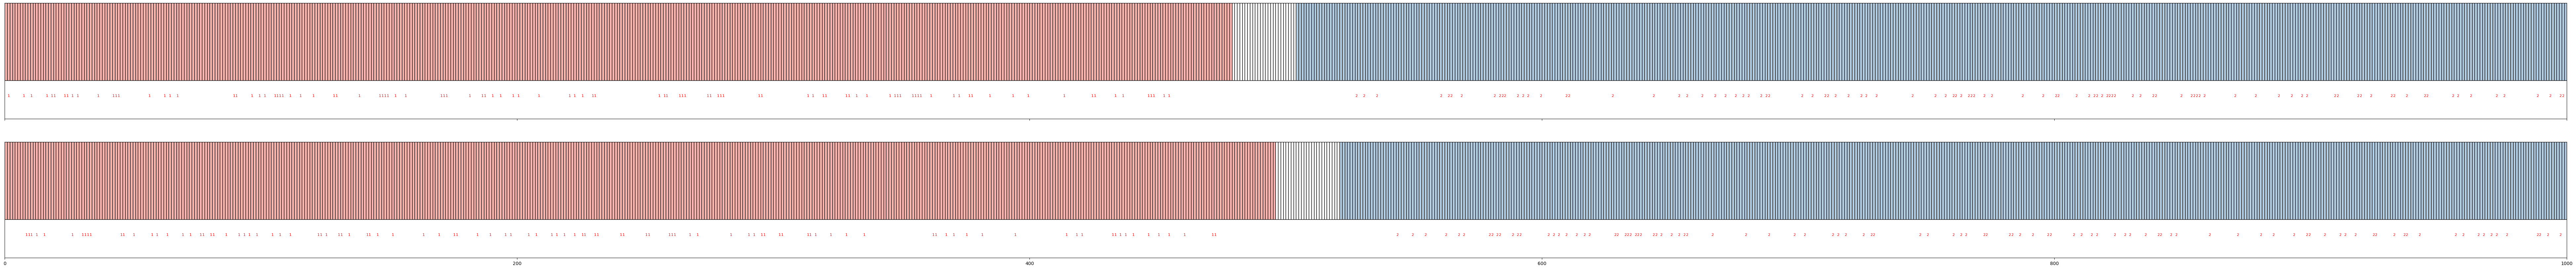

In [12]:
avg, lo_score, lo_pair = predict_interpretability(fake_policy, SigmoidPlayer, info, n_children)
print(f"Average interpretability: {avg}")
print(f"Greatest disagreement: {lo_score}")
_, ax = plt.subplots(nrows=2, sharex=True, figsize=(100, 10))
ax[0] = lo_pair[0].plot_strategy(ax[0])
ax[1] = lo_pair[1].plot_strategy(ax[1])
plt.show()

### Multi-layer Perceptron Player
Implements scikit-learn's `MLPClassifier` [citation needed] which assings a confidence score to each state in it's policy. Then, the threshold is applied to those scores. This approach is shared by the remaining classifiers implemented using the scikit-learn API. 



https://scikit-learn.org/1.6/about.html#citing-scikit-learn

Average interpretability: 0.9706159595959579
Greatest disagreement: 0.9465


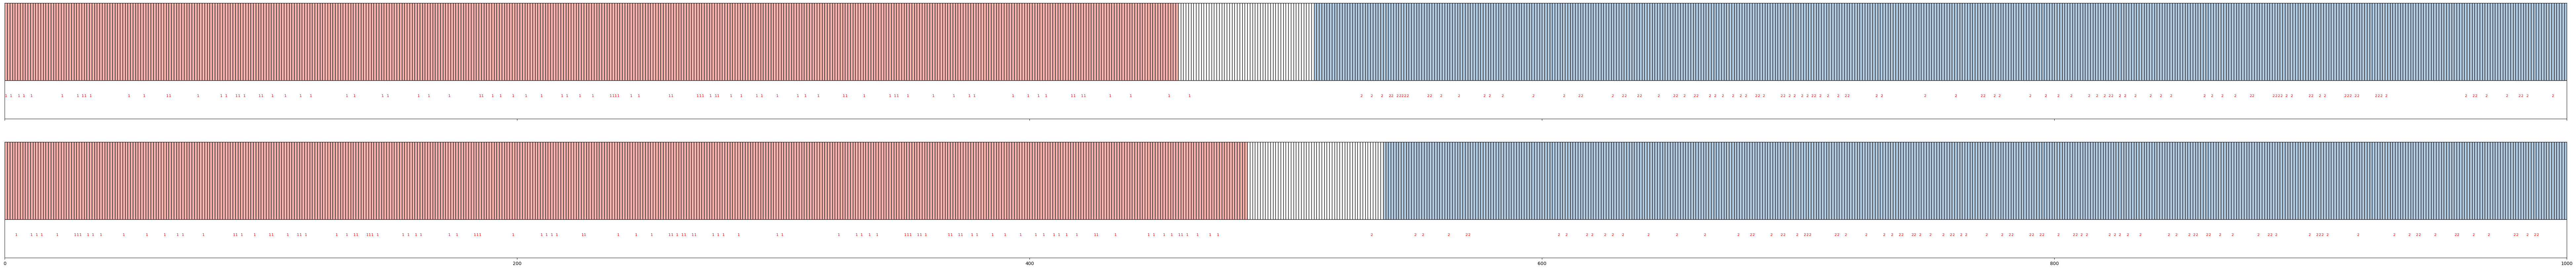

In [13]:
avg, lo_score, lo_pair = predict_interpretability(fake_policy, MLPPlayer, info, n_children)
print(f"Average interpretability: {avg}")
print(f"Greatest disagreement: {lo_score}")
_, ax = plt.subplots(nrows=2, sharex=True, figsize=(100, 10))
ax[0] = lo_pair[0].plot_strategy(ax[0])
ax[1] = lo_pair[1].plot_strategy(ax[1])
plt.show()

### Linear Regression Player
Implements scikit-learn's `LinearRegressionClassifier`.

Average interpretability: 0.9896606060606071
Greatest disagreement: 0.974


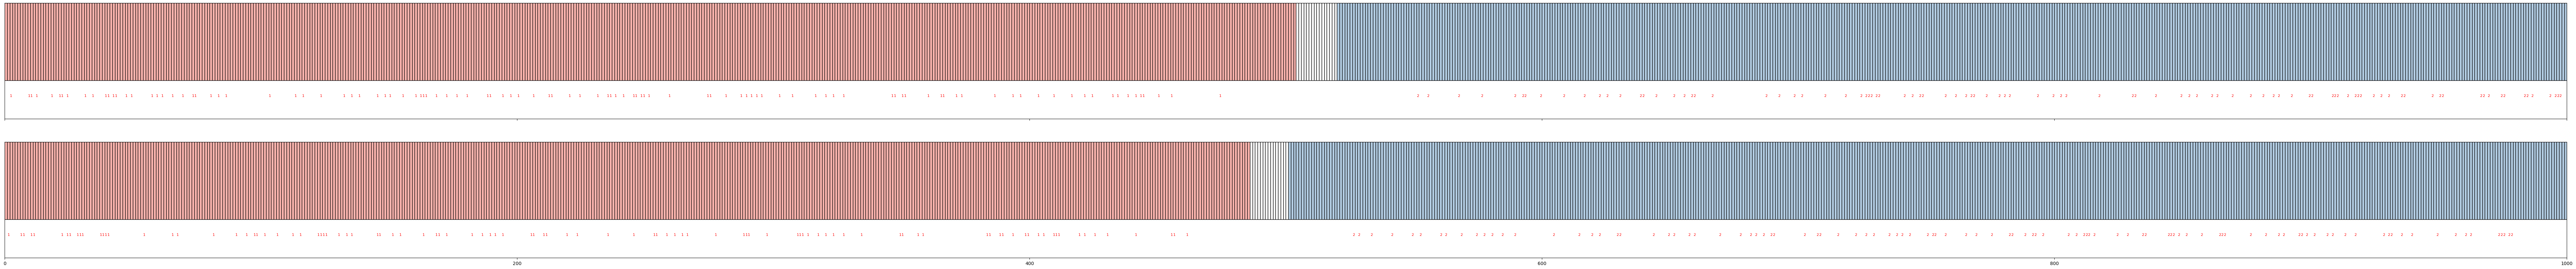

In [14]:
avg, lo_score, lo_pair = predict_interpretability(fake_policy, LRPlayer, info, n_children)
print(f"Average interpretability: {avg}")
print(f"Greatest disagreement: {lo_score}")
_, ax = plt.subplots(nrows=2, sharex=True, figsize=(100, 10))
ax[0] = lo_pair[0].plot_strategy(ax[0])
ax[1] = lo_pair[1].plot_strategy(ax[1])
plt.show()

### Naive Bayes Player
Implements scikit-learn's `GaussianNB` classifier.

Average interpretability: 0.9375408080808133
Greatest disagreement: 0.8955


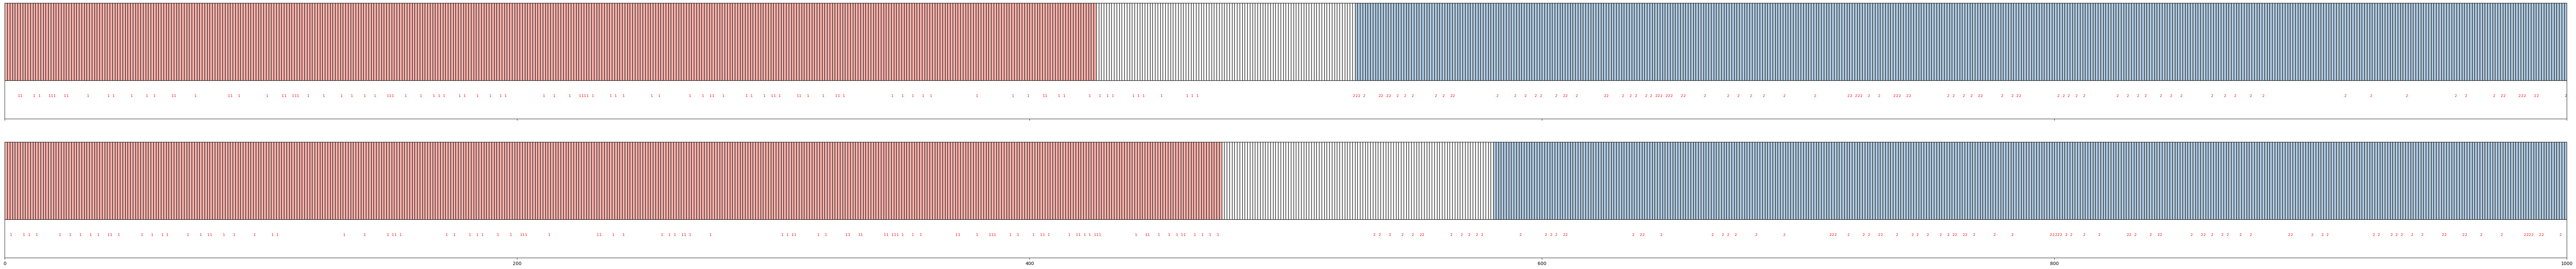

In [15]:
avg, lo_score, lo_pair = predict_interpretability(fake_policy, NaiveBayesPlayer, info, n_children)
print(f"Average interpretability: {avg}")
print(f"Greatest disagreement: {lo_score}")
_, ax = plt.subplots(nrows=2, sharex=True, figsize=(100, 10))
ax[0] = lo_pair[0].plot_strategy(ax[0])
ax[1] = lo_pair[1].plot_strategy(ax[1])
plt.show()